In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import ConfusionMatrixDisplay

# Carregando a base de dados
dados_iris = load_iris()
tabela = pd.DataFrame(data = dados_iris.data, columns = dados_iris.feature_names)
tabela['especie'] = dados_iris.target

# Separando variáveis preditoras e a meta
X = tabela.drop('especie', axis = 1)
y = tabela['especie']

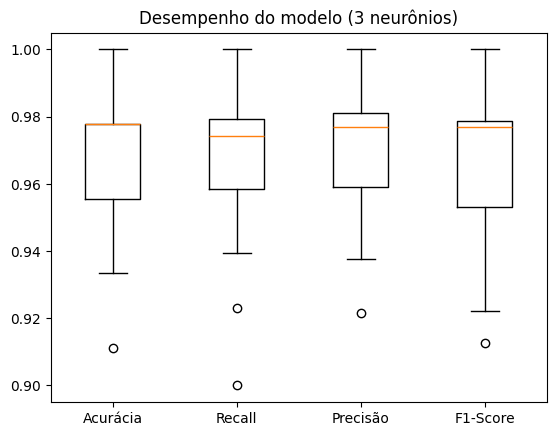

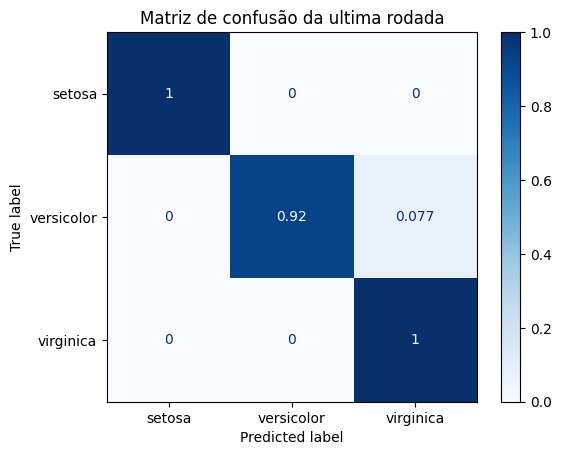

In [ ]:
# Criando o robô com mais tempo para treinar (evita avisos)
rede_neural = MLPClassifier(hidden_layer_sizes=(3,), max_iter = 1000,  random_state=42)

lista_acuracia, lista_recall, lista_precisao, lista_f1 = [], [], [], []

for rodada in range(1, 31):
    # cada rodada terá um corte diferente!
    X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.30)

    rede_neural.fit(X_treino, y_treino)
    previsoes = rede_neural.predict(X_teste)

    lista_acuracia.append(accuracy_score(y_teste, previsoes))
    lista_recall.append(recall_score(y_teste, previsoes, average ='macro', zero_division = 0))
    lista_precisao.append(precision_score(y_teste, previsoes, average ='macro', zero_division = 0))
    lista_f1.append(f1_score(y_teste, previsoes, average ='macro', zero_division = 0))

# Criando e exibindo o boxplot
plt.boxplot([lista_acuracia, lista_recall, lista_precisao, lista_f1])
plt.title("Desempenho do modelo (3 neurônios)")
plt.xticks([1, 2, 3, 4], ['Acurácia', 'Recall', 'Precisão', 'F1-Score'])
plt.show()

# Imprimindo a matriz da última rodada
matriz_percentual = confusion_matrix(y_teste, previsoes, normalize='true')
visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_percentual, display_labels = dados_iris.target_names)
visualizacao.plot(cmap = 'Blues')
plt.title("Matriz de confusão da ultima rodada")
plt.show()

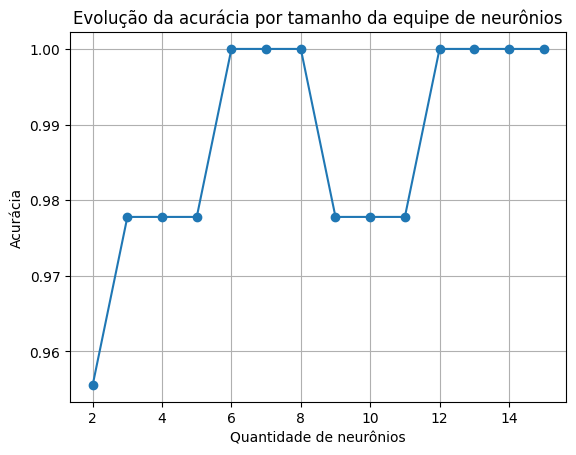

In [ ]:
# Exploração do número de neurônios (2 a 15)
lista_exploracao = []
valores_neuronios = range(2, 16)

# Um único corte fixo para testar todo mundo de forma justa
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.30, random_state = 42)

for equipe in valores_neuronios:
  # Criando o robô da rodada com o número de neurônios atual
  rede_neural_dinamica = MLPClassifier(hidden_layer_sizes = (equipe, ), max_iter = 2000, random_state = 42)

  rede_neural_dinamica.fit(X_treino, y_treino)

  previsoes = rede_neural_dinamica.predict(X_teste)

  nota_acuracia = accuracy_score(y_teste, previsoes)

  lista_exploracao.append(nota_acuracia)

# Desenhando o gráfico de linha
plt.plot(valores_neuronios, lista_exploracao, marker = 'o')
plt.xlabel('Quantidade de neurônios')
plt.ylabel('Acurácia')
plt.title('Evolução da acurácia por tamanho da equipe de neurônios')
plt.grid(True)
plt.show()

In [ ]:
# Otimização com GridSearchCV separada por função

grade_parametros = {
    'hidden_layer_sizes': [(equipe,) for equipe in range(2, 16)],
    'activation': ['relu', 'tanh', 'logistic']
}

# 2. Criação do robô básico e da máquina de testes
robo_base = MLPClassifier(max_iter=2000, random_state=42)

maquina_grid = GridSearchCV(estimator=robo_base, param_grid=grade_parametros, cv=30)
maquina_grid.fit(X, y)

resultados = pd.DataFrame(maquina_grid.cv_results_)

print("--- MELHOR CONFIGURAÇÃO POR FUNÇÃO DE ATIVAÇÃO ---")
for funcao in ['relu', 'tanh', 'logistic']:
    dados_funcao = resultados[resultados['param_activation'] == funcao]
    melhor_linha = dados_funcao.loc[dados_funcao['mean_test_score'].idxmax()]

    neuronios = melhor_linha['param_hidden_layer_sizes']
    nota = melhor_linha['mean_test_score']
    print(f"Função {funcao}: Melhor com {neuronios} neurônios (Acurácia Média: {nota:.4f})")

print("\n--- VENCEDOR GERAL ---")
vencedor_geral = maquina_grid.best_params_
melhor_nota_geral = maquina_grid.best_score_
print(f"A combinação campeã foi: {vencedor_geral} com acurácia de {melhor_nota_geral:.4f}")

--- MELHOR CONFIGURAÇÃO POR FUNÇÃO DE ATIVAÇÃO ---
Função relu: Melhor com (12,) neurônios (Acurácia Média: 0.9867)
Função tanh: Melhor com (12,) neurônios (Acurácia Média: 0.9867)
Função logistic: Melhor com (3,) neurônios (Acurácia Média: 0.9800)

--- VENCEDOR GERAL ---
A combinação campeã foi: {'activation': 'relu', 'hidden_layer_sizes': (12,)} com acurácia de 0.9867
